# Main analysis 2

Here we explore surface-based data from the datasets available through `neuromaps`

In [1]:
import sys
sys.path.append("../")

from config import *
from figs_config import *

Loaded aesthetics module


* aesthetics

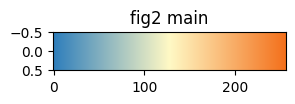

In [2]:
# main colour maps
gnrd,_ = three_colours_gradient(lo=plt.cm.Blues(0.7), mid=plt.cm.YlOrBr(0.1), hi=plt.cm.Oranges(0.6), plot=False)
show_colour_scheme(gnrd, "fig2 main")

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Get an existing colormap and sample a segment
lincmap = plt.get_cmap('Grays')
pct_colours = lincmap(np.linspace(0.3, .9, len(test_percentages)))
#sns.color_palette(pct_colours)

In [4]:
corder = ['gene expression', 'MEG', 'structural', 'functional', 'metabolism', 'expansion']
ccolours = [
    to_hex(plt.cm.terrain(0.2)),  # gene: light turquoise
    to_hex(plt.cm.spring(0.65)),  # MEG: orange
    to_hex(plt.cm.cubehelix(0.7)),  # structural: violet
    to_hex(plt.cm.terrain(0.3)),  # functional: green
    to_hex(plt.cm.nipy_spectral(0.3)), # metabolism: blue
    to_hex(plt.cm.spring(0.37)) # expansion: pink
]

cpal = dict(zip(corder, ccolours))
#sns.color_palette(ccolours)

# Specify data

In [5]:
import pandas as pd
maptags = pd.read_table(projdir + '/data/surf_map_names', delimiter = " ", dtype = str)
maptags = list(maptags.columns)

In [6]:
space = 'fsLR-4k'
#maptag = 'abagen_genepc1'
geometry = 'reduced-midthickness'
datasource = 'neuromaps'
strategy = 'dsk33'
#percentage = 5
niters = 100

In [7]:
import joblib
src_pvdata = joblib.load( projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')

# Data

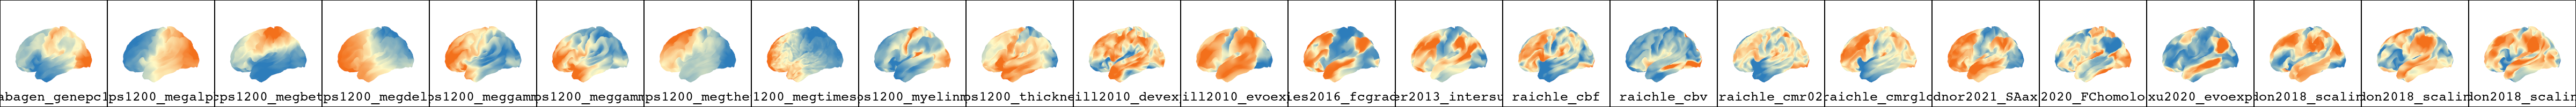

In [9]:
import pyvista as pv

pl = pv.Plotter(shape = (1, len(maptags)), window_size = (4800, 200))

for mi, maptag in enumerate(maptags):
    pl.subplot(0,mi)
    pl.add_mesh(src_pvdata.rotate_z(180), scalars=maptag, cmap = gnrd, \
                clim = (np.percentile(src_pvdata[maptag], 5), np.percentile(src_pvdata[maptag], 95)), \
                **mesh_aes)
    pl.add_text(maptag, font_size = 10, font='courier', position = 'lower_edge')
    pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/neuromaps_instances.svg')

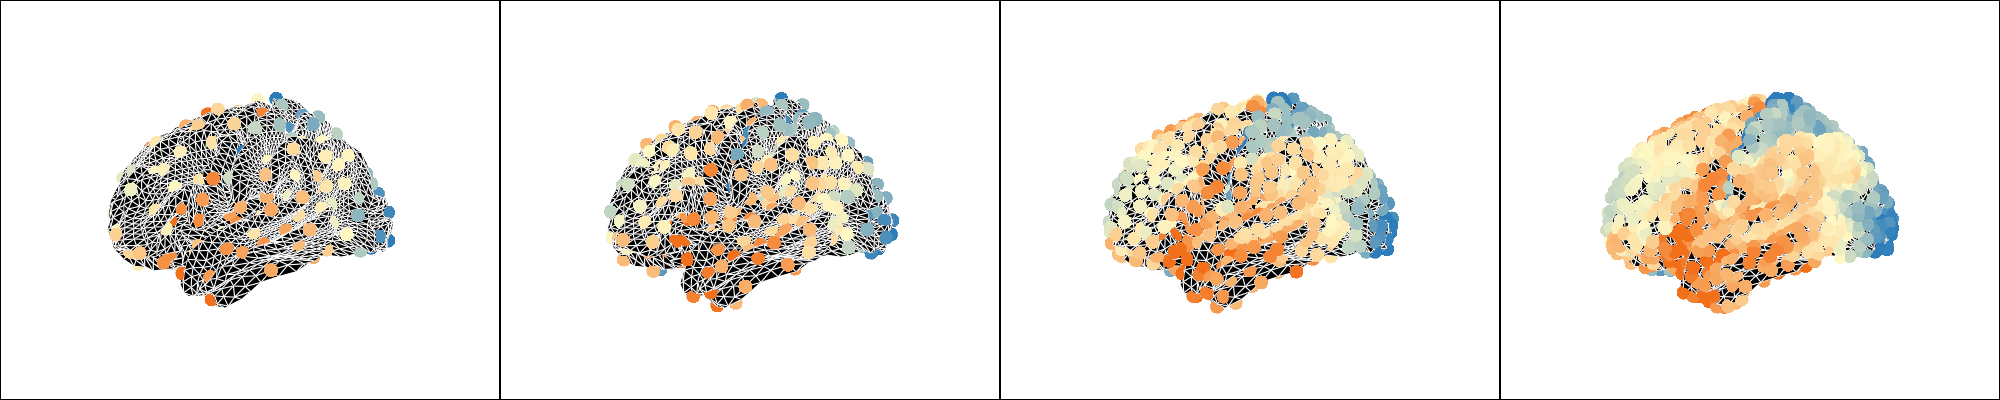

In [10]:
import pyvista as pv

pl = pv.Plotter(shape = (1, len(test_percentages)), window_size = (2000,400))

strategy = 'fibonacci'
for pi, percentage in enumerate(test_percentages):

    sampling = joblib.load( projdir + f'/data/sampling/{space}_{geometry}_samp-{strategy}_pct-{str(percentage)}.pkl')
    known_coords, known_verts, unknown_coords, unknown_verts = sampling[1]
    pl.subplot(0, pi)
    pl.add_mesh(src_pvdata.rotate_z(180), show_edges=True, edge_color = 'w', color = 'k', **mesh_aes)
    pl.add_points(pv.PolyData(known_coords[:,:,0]).rotate_z(180), scalars = src_pvdata['hcps1200_thickness'][known_verts.flatten().astype(int)], \
                  cmap = gnrd, point_size = 14, clim = (np.percentile(src_pvdata['hcps1200_thickness'], 5), np.percentile(src_pvdata['hcps1200_thickness'], 95)), show_scalar_bar=False, **point_aes)
    pl.camera_position = 'yz'
    
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/fslr4k_fibonacci_samples_different_percentages.svg')

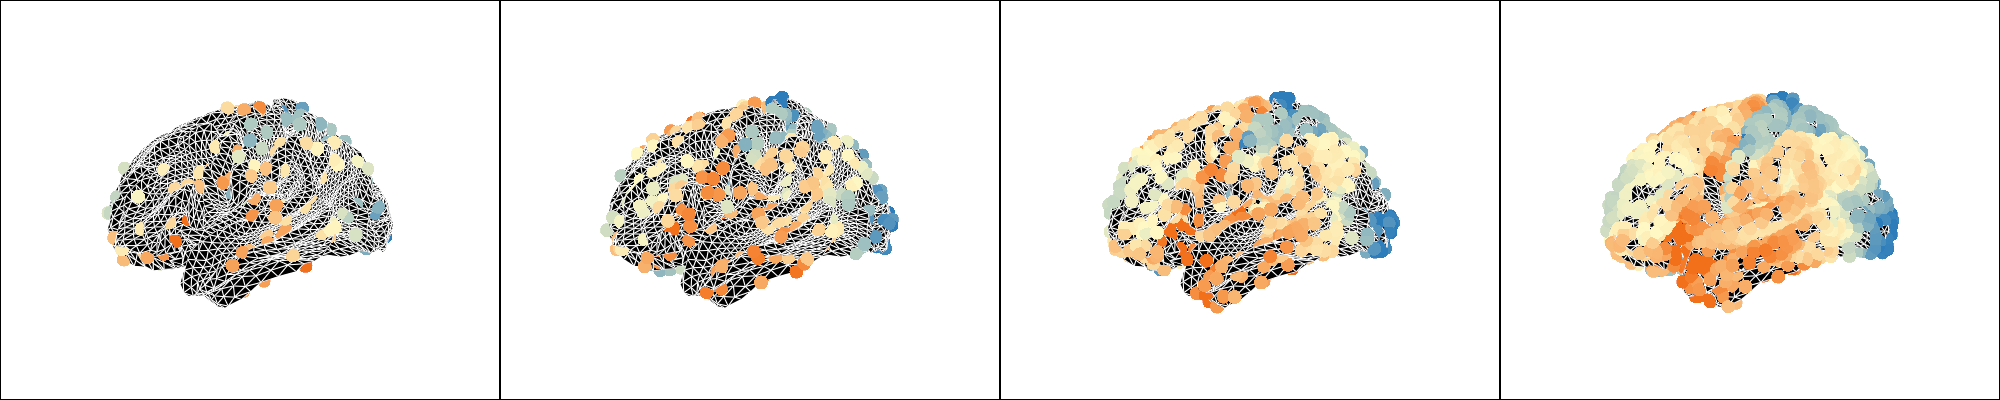

In [11]:
import pyvista as pv

pl = pv.Plotter(shape = (1, len(test_percentages)), window_size = (2000,400))

strategy = 'dsk33'
for pi, percentage in enumerate(test_percentages):

    sampling = joblib.load( projdir + f'/data/sampling/{space}_{geometry}_samp-{strategy}_pct-{str(percentage)}_iters-100.pkl')
    known_coords, known_verts, unknown_coords, unknown_verts = sampling[1]
    pl.subplot(0, pi)
    pl.add_mesh(src_pvdata.rotate_z(180), show_edges=True, edge_color = 'w', color = 'k', **mesh_aes)
    pl.add_points(pv.PolyData(known_coords[:,:,0]).rotate_z(180), clim = (np.percentile(src_pvdata['hcps1200_thickness'], 5), np.percentile(src_pvdata['hcps1200_thickness'], 95)), \
                  scalars = src_pvdata['hcps1200_thickness'][known_verts[:,0].flatten().astype(int)],\
                  cmap = gnrd, \
                  point_size = 14, show_scalar_bar=False, **point_aes)
    pl.camera_position = 'yz'
    
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/fslr4k_dsk33_samples_different_percentages.svg')

# Sampling

In [8]:
strategy = 'dsk33'

import matplotlib.pyplot as plt
from scipy.stats import zscore

all_standardized_voronoi_se = []
offset = -10

voronoi_se = np.zeros((niters, len(test_percentages)))
voronoi_se_zscored = np.zeros((niters, len(test_percentages)))

for pi, p in enumerate(test_percentages):
    labels, results = joblib.load(projdir + \
        f'/results/{datasource}/{strategy}/{space}_{maptags[0]}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
    
    for i in range(niters):
        voronoi_se[i, pi] = results[0][i][2]

    voronoi_se_zscored[:,pi] = zscore( voronoi_se[:,pi] )

all_standardized_voronoi_se.append(voronoi_se_zscored)

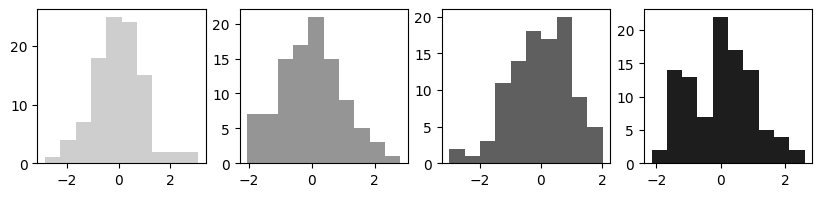

In [9]:
fig, axs = plt.subplots(1,4, figsize = (10,2))
for i in range(len(test_percentages)):
    axs[i].hist( all_standardized_voronoi_se[0][:,i], color=pct_colours[i])
plt.show()

In [13]:
all_standardized_voronoi_se[0].shape

(100, 4)

# Moran scatterplots of the original maps

In [102]:
from interpmodules import helpers

global_i_s = pd.DataFrame(index = maptags, columns = ['i'])

Dist = helpers.internal_distance_matrix(src_pvdata.points, 'euclidean')

for maptag in maptags:
    global_i = helpers.morans_i(Dist, src_pvdata[maptag], normalize=True)
    global_i_s.loc[maptag] = global_i

In [105]:
from scipy.sparse import coo_matrix

dist = 1 / Dist
np.fill_diagonal(dist, 0)
dist /= dist.sum(axis=-1, keepdims=True)
spdist = coo_matrix(dist)

In [106]:
def moran_permutation_test(x, W, n_perm=9999, alternative="two-sided", seed=0):
    rng = np.random.default_rng(seed)

    I_obs = helpers.morans_i(W, x, normalize=True, local=False, invert_dist=True)
    z = x - np.mean(x)

    # precompute denom for speed; permuting z doesn't change denom
    denom = np.dot(z, z)
    if denom == 0:
        return I_obs, np.nan, None

    Iz = np.empty(n_perm, dtype=float)
    for b in range(n_perm):
        zp = rng.permutation(z)
        Iz[b] = np.dot(zp, W @ zp) / denom

    # p-value with +1 correction (recommended)
    if alternative == "greater":      # positive autocorrelation
        p = (np.sum(Iz >= I_obs) + 1) / (n_perm + 1)
    elif alternative == "less":       # negative autocorrelation
        p = (np.sum(Iz <= I_obs) + 1) / (n_perm + 1)
    elif alternative == "two-sided":
        p = (np.sum(np.abs(Iz) >= abs(I_obs)) + 1) / (n_perm + 1)
    else:
        raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")

    return I_obs, p, Iz

In [ ]:
pperm = np.zeros(len(maptags))
for mi, maptag in enumerate(maptags):
    pperm[mi] = moran_permutation_test(src_pvdata[maptag], dist, n_perm=1000)[1]

In [151]:
pperm

array([0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999])

In [107]:
global_i_s = joblib.load(projdir + '/results/stats/neuromaps_full_global_i_s.pkl')

ERROR! Session/line number was not unique in database. History logging moved to new session 40


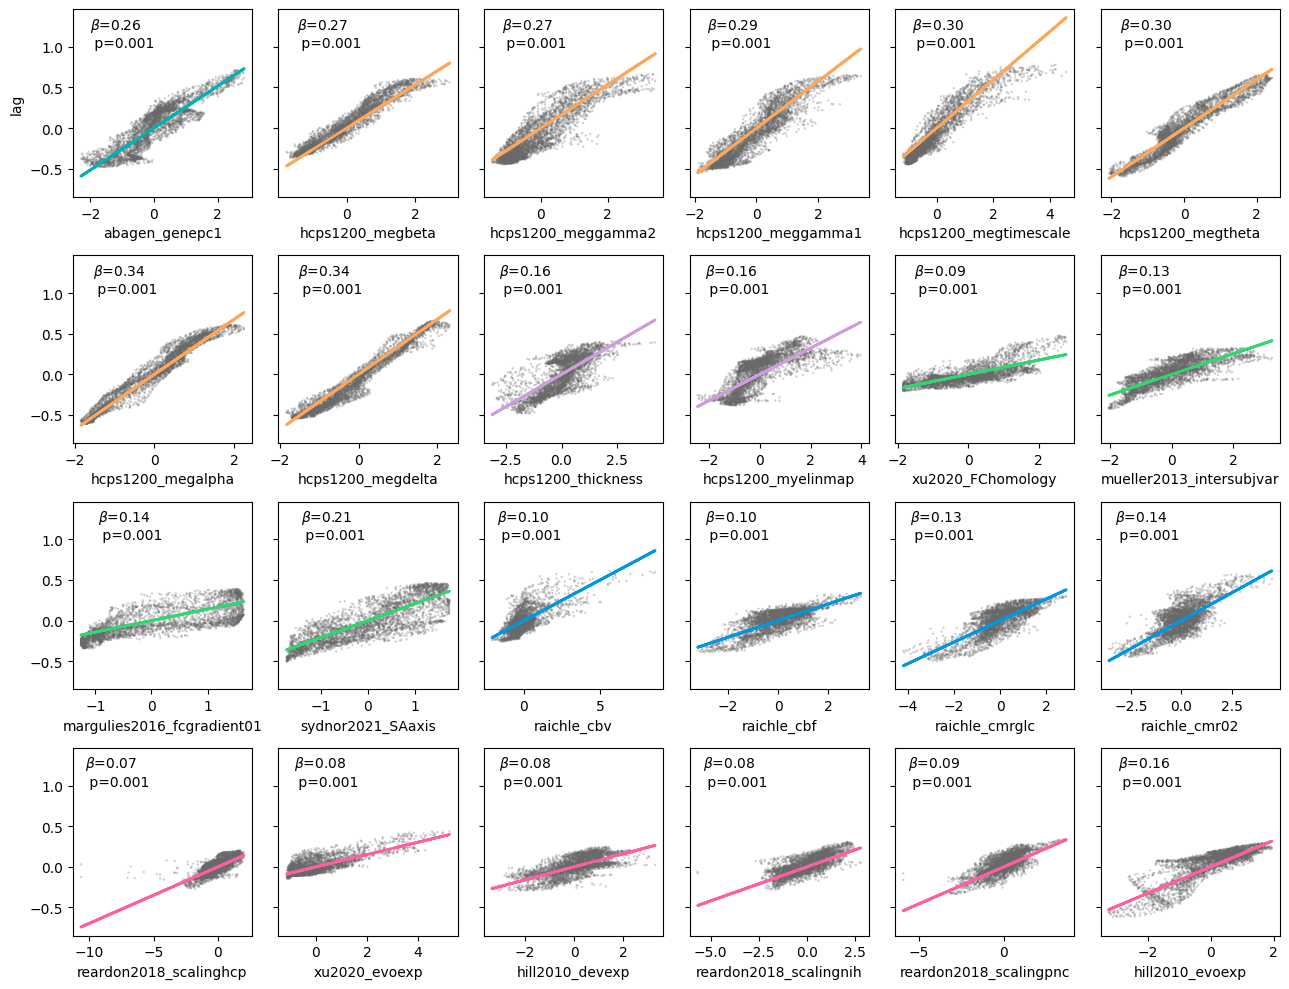

In [127]:
from scipy.stats import zscore

fig, axs = plt.subplots(4, 6, figsize = (13, 10), sharey=True)

moran_scatter = pd.DataFrame()

for mi, maptag in enumerate(global_i_s.index):


    row, col = mi // 6, mi % 6
    
    zX = zscore(src_pvdata[maptag])
    #splag = np.average(np.repeat(zX[np.newaxis], src_pvdata.n_points, axis=0), weights=spdist, axis=1)
    splag = spdist @ zX
    normalized_og = zscore(src_pvdata[maptag])
    axs[row, col].scatter(x = zX, y =splag, s=3, c='dimgray', edgecolor = 'none', alpha = .3, rasterized = True)
    axs[row, col].set_xlabel(maptag)
    axs[0,0].set_ylabel("lag")

    #axs[mi].axhline(0, color="k", lw=1)
    #axs[mi].axvline(0, color="k", lw=1)
    
    # regression line
    m = (zX @ splag) / (zX @ zX)   # Moran's I
    moran_scatter.at[maptag,0] = m
    axs[row,col].plot(zX, m * zX, linewidth = 2, color=cpal[global_i_s.at[maptag, 'category']])
    axs[row,col].text(x=zX.min() + 0.3, y=1, s=r"$\beta$=" + "%.2f" % m + "\n p=0.001")
plt.tight_layout()

plt.savefig(projdir + '/figs/main/neuromaps_moran_scatterplots.svg')

# Variography

* functional PCA on the empirical variograms

In [8]:
import matplotlib.pyplot as plt
nh = 25
X = src_pvdata.points
x = src_pvdata['hcps1200_thickness']

In [9]:
from interpmodules import helpers

Dist = helpers.internal_distance_matrix(src_pvdata.points)

In [10]:
EDist = helpers.internal_distance_matrix(src_pvdata.points, "euclidean")

import nibabel as nb
gimg = nb.load('/home/yzhou/projects/interpolate/data/atlases/fsLR/tpl-fsLR_den-4k_hemi-L_midthickness.surf.gii')
v,f = gimg.darrays[0].data, gimg.darrays[1].data
GDist = helpers.internal_distance_matrix(v,f, "geodesic")

In [11]:
medialwall = joblib.load('/home/yzhou/projects/interpolate/data/fsLR-4k_midthickness_neuromaps_medial_wall_mask.pkl')

In [12]:
tmp = np.delete(GDist, medialwall, axis=0)
tmp1 = np.delete(tmp, medialwall, axis=1)

In [13]:
GDist = tmp1

In [14]:
import pandas as pd

N = dict.fromkeys(['euclidean', 'geodesic'])

In [15]:
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree

max_lag = np.nanmax(EDist)
tree = KDTree(src_pvdata.points)
spdist = tree.sparse_distance_matrix(tree, max_distance=max_lag, output_type='coo_matrix')

i_idx = spdist.row
j_idx = spdist.col
dist_ij = spdist.data

var = .5 * (x[i_idx] - x[j_idx])**2

df = pd.DataFrame({
    'h': dist_ij,
    'ev': var
})

bin_edges = np.linspace(0.000001, max_lag, nh + 1)
df['bins'] = pd.cut(df['h'], bin_edges)

N['euclidean'] = df.groupby('bins')['ev'].count().values

In [16]:
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree

max_lag = np.nanmax(GDist)
spdist = coo_matrix(GDist)

i_idx = spdist.row
j_idx = spdist.col
dist_ij = spdist.data

var = .5 * (x[i_idx] - x[j_idx])**2

df = pd.DataFrame({
    'h': dist_ij,
    'ev': var
})

bin_edges = np.linspace(0.000001, max_lag, nh + 1)
df['bins'] = pd.cut(df['h'], bin_edges)

N['geodesic'] = df.groupby('bins')['ev'].count().values

In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,nh))
cmap_discrete = ListedColormap(colors)

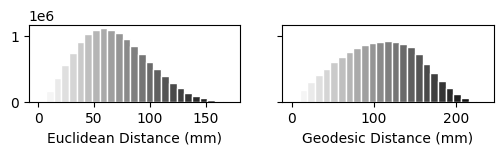

In [18]:
figs, axs = plt.subplots(1,2, figsize = (6,1), sharey=True)

bin_edges = np.linspace(0.000001, np.nanmax(EDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

axs[0].bar(x=bincenters, height=N["euclidean"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
axs[0].set_xlabel("Euclidean Distance (mm)")

bin_edges = np.linspace(0.000001, np.nanmax(GDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

axs[1].bar(x=bincenters, height=N["geodesic"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
axs[1].set_xlabel("Geodesic Distance (mm)")

plt.savefig(projdir + '/figs/main/supplements_neuromaps_dist_bins.svg')

In [23]:
np.where(N['euclidean'] == N['euclidean'].max())

(array([8]),)

In [25]:
print(bin_edges[7], bin_edges[8])

65.63982 75.01694


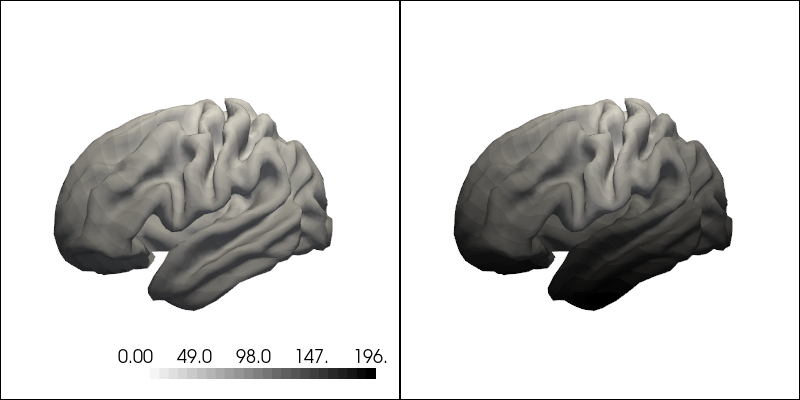

In [17]:
import copy
import pyvista as pv
from matplotlib.colors import ListedColormap
N=25
cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,N))
cmap_discrete = ListedColormap(colors)

pl = pv.Plotter(shape = (1,2), window_size = (800,400))

#pl.add_points(sphere_mesh.points[12], color = 'r', point_size = 12,  **point_aes)
pl.subplot(0,0)
pl.add_mesh(copy.deepcopy(src_pvdata).rotate_z(200), scalars=EDist[500], smooth_shading=True, opacity=1, cmap = cmap_discrete)
pl.camera_position = 'yz'

pl.subplot(0,1)
pl.add_mesh(copy.deepcopy(src_pvdata).rotate_z(200), scalars=GDist[500], smooth_shading=True, opacity =1, cmap = cmap_discrete)

pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/supplements_neuromaps_edist_gdist_midthickness_bins.svg')

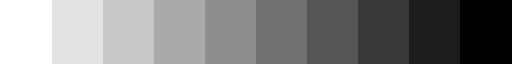

In [41]:
cmap_discrete

In [ ]:
import joblib

# h should be the same
nh = 25
all_ev = np.zeros((nh, len(maptags)))

for mi, maptag in enumerate(maptags):

    h, ev, _ = helpers.get_empirical_variogram_fast(x=src_pvdata[maptag], X=src_pvdata.points, D=Dist,nh=nh)
    all_ev[:,mi] = ev

joblib.dump( (h, all_ev), projdir + '/results/stats/neuromaps_collected_expvgm.pkl')

In [16]:
h, all_ev = joblib.load( projdir + '/results/stats/neuromaps_collected_expvgm.pkl' )

In [17]:
from skfda.representation.grid import FDataGrid
from scipy.stats import zscore

all_ev_z = zscore(all_ev, axis = 0)
datag = FDataGrid(all_ev_z)

In [18]:
import skfda

fpca = skfda.preprocessing.dim_reduction.FPCA(n_components=3, )

In [19]:
fpca.fit(datag)

FPCA(_weights=array([0.01449275, 0.05797101, 0.02898551, 0.05797101, 0.02898551,
       0.05797101, 0.02898551, 0.05797101, 0.02898551, 0.05797101,
       0.02898551, 0.05797101, 0.02898551, 0.05797101, 0.02898551,
       0.05797101, 0.02898551, 0.05797101, 0.02898551, 0.05797101,
       0.02898551, 0.05434783, 0.04347826, 0.01811594]),
     n_components=3)

In [20]:
curve_colours = [cpal['gene expression']]+ [cpal['MEG']]*7 + [cpal['structural']]*2 + [cpal['expansion']]*2 + [cpal['functional']]*2 + [cpal['metabolism']]*4 + [cpal['functional']] * 2 + [cpal['expansion']]*4

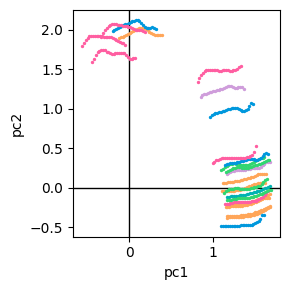

In [21]:
import matplotlib.pyplot as plt


plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

for x, y, mi in zip(xs, ys, np.arange(len(maptags))):
    plt.scatter(
        x + h*0.003,
        y + all_ev_z[:,mi]*0.04,
        color=curve_colours[mi],
        alpha=1, s = 2, zorder = 10
    )

plt.scatter(xs, ys, s=0, zorder=10)

plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()

#plt.savefig(projdir + '/figs/main/neuromaps_map_variogram_functional-pca.svg')
#plt.show()

In [22]:
fpca.explained_variance_

array([0.74224887, 0.2084329 , 0.0535849 ])

In [23]:
fpca.singular_values_

array([4.22066025, 2.23660227, 1.13403603])

In [24]:
pcs = fpca.fit_transform(datag)

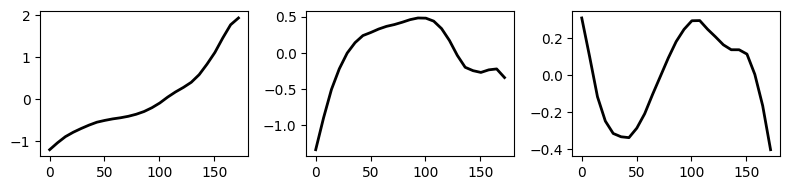

In [128]:
fig, axs = plt.subplots(1,3, figsize = (8, 2))

for c in range(fpca.n_components):
    axs[c].plot(h, pcs[:,c], color = 'k', linewidth=2)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_variograms_fullmaps_fpca_components.svg')

## Exprimental variograms as little squares

In [136]:
import matplotlib.pyplot as plt
import skgstat as skg

maptags = list(global_i_s.index)

full_emp_x_s = []
full_emp_ev_s = []

all_ev = np.zeros((25, len(maptags)))

for mi, maptag in enumerate(maptags):

    h, ev, _ = helpers.get_empirical_variogram_fast(x=src_pvdata[maptag], X=src_pvdata.points, D=Dist,nh=nh)
    all_ev[:,mi] = ev
    
    
    binned_vgm = skg.Variogram(values=src_pvdata[maptag],\
                                                          coordinates=src_pvdata.points, \
                                                          model='exponential', n_lags=25, \
                                                         bin_func = 'even', dist_func='euclidean', fit = 'trf', use_nugget=True)
    full_emp_x, full_emp_y=binned_vgm.get_empirical(bin_center=True)
    bounds=(0.00001, [np.nanmax(full_emp_x), np.nanmax(full_emp_y), np.nanmax(full_emp_y) / 10])
    binned_vgm.fit(force=True,method='trf',p0=bounds[1],maxfev=1000)

    full_eff_range, full_psill, full_nugg = binned_vgm.parameters
    
    full_emp_fit = [ helpers.exponential(h=xi, r=full_eff_range, c0=full_psill, nugget=full_nugg) for xi in full_emp_x ]

    full_emp_x_s.append(full_emp_x)
    full_emp_ev_s.append(full_emp_fit)


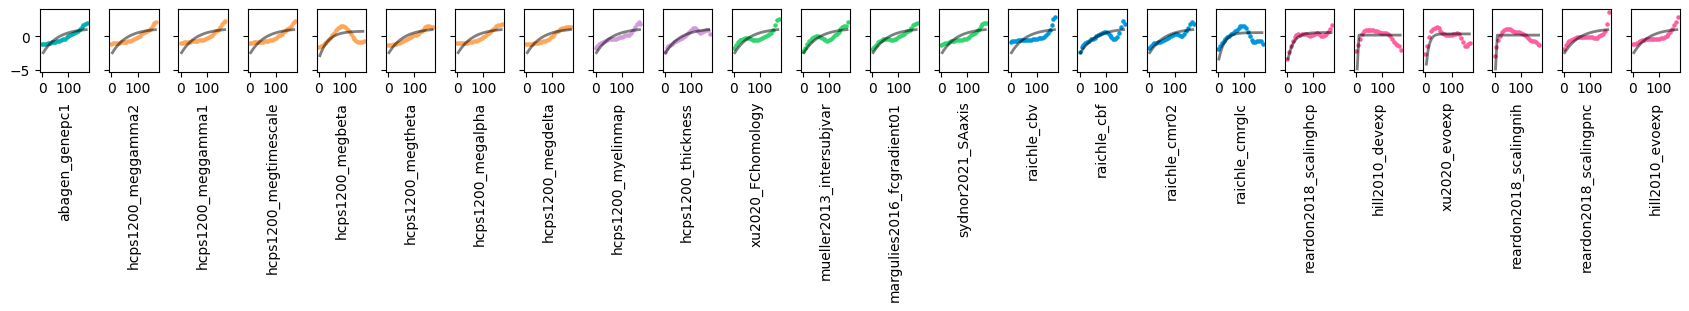

In [139]:
fig, axs = plt.subplots(1, len(maptags), figsize = (17,3.25), sharex=True, sharey=True)

for mi, maptag in enumerate(maptags):
    axs[mi].scatter( x=h, y=zscore(all_ev[:,mi]), color=cpal[global_i_s.at[maptag, 'category']], s=5 )
    axs[mi].plot( full_emp_x_s[mi], zscore(full_emp_ev_s[mi]), c='k', linewidth = 2, alpha = 0.5 )
    axs[mi].set_xlabel(maptag, rotation = 90)
plt.tight_layout()
#plt.show()

plt.savefig( projdir + '/figs/main/neuromaps_vgm_squiggles.svg')

# Normal PCA

In [82]:
# Principle components
from sklearn.decomposition import PCA

pca = PCA(n_components=2, svd_solver = 'full', random_state=321)
pca.fit(all_ev_z)

PCA(n_components=2, random_state=321, svd_solver='full')

In [83]:
pc1 = pca.fit_transform(all_ev_z)[:,0]
pc2 = pca.fit_transform(all_ev_z)[:,1]

In [84]:
print(pca.explained_variance_ratio_)

[0.70678324 0.20317342]


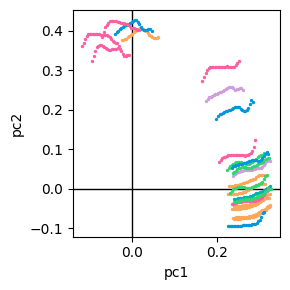

In [89]:
import matplotlib.pyplot as plt


plt.subplots(figsize = (3,3))

xs = np.array(pca.components_[0]).flatten()
ys = np.array(pca.components_[1]).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

for x, y, mi in zip(xs, ys, np.arange(len(maptags))):
    plt.scatter(
        x + h*0.0005,
        y + all_ev_z[:,mi]*0.01,
        color=curve_colours[mi],
        alpha=1, s = 2, zorder = 10
    )

plt.scatter(xs, ys, s=0, zorder=10)

plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()

plt.savefig(projdir + '/figs/main/neuromaps_map_variogram_pca.svg')

# Iterations of variograms (DSK33)

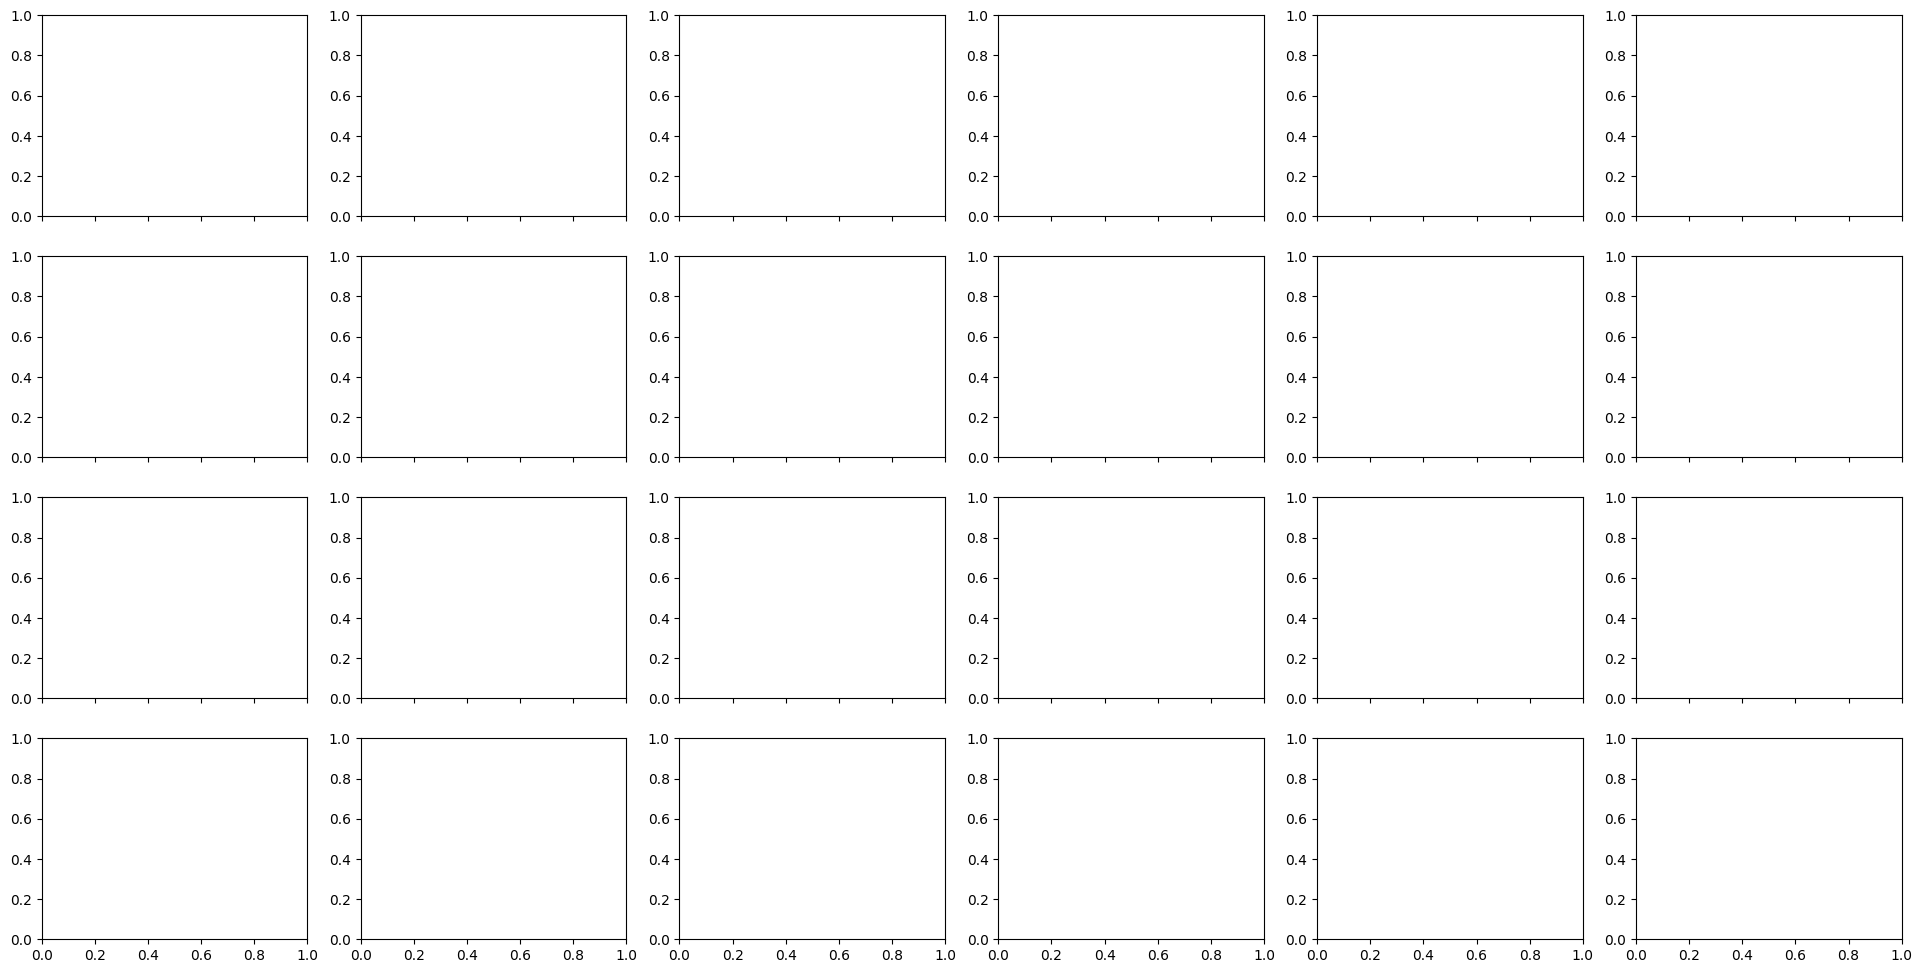

In [20]:
from interpmodules import helpers, metrics
import skgstat as skg
from scipy.stats import zscore

variogram_gof = []
variogram_percentages = []
variogram_maptags = []

fig, axs = plt.subplots(4,6, figsize = (24, 12), sharex=True)

Dist = helpers.internal_distance_matrix(src_pvdata.points)

for mi, maptag in enumerate(maptags):
    
    binned_vgm = skg.Variogram(values=zscore(src_pvdata[maptag]),\
                                                          coordinates=src_pvdata.points, \
                                                          model='exponential', n_lags=25, \
                                                         bin_func = 'even', dist_func='euclidean', fit = 'trf', use_nugget=True)
    full_emp_x, full_emp_y=binned_vgm.get_empirical(bin_center=True)
    bounds=(0.00001, [np.nanmax(full_emp_x), np.nanmax(full_emp_y), np.nanmax(full_emp_y) / 10])
    binned_vgm.fit(force=True,method='trf',p0=bounds[1],maxfev=1000)

    full_eff_range, full_psill, full_nugg = binned_vgm.parameters
    
    full_emp_fit = [ helpers.exponential(h=xi, r=full_eff_range, c0=full_psill, nugget=full_nugg) for xi in full_emp_x ]
    
    variogram_gof.append( np.mean( metrics.metric( full_emp_y, full_emp_fit, 'residual') ) / (psill + nugg) )
    variogram_maptags.append(maptag)

In [24]:
import pandas as pd
variogram_gof_plotdata = pd.DataFrame()

In [25]:
variogram_gof_plotdata['mae'] = variogram_gof
#variogram_gof_plotdata['percentage'] = variogram_percentages
variogram_gof_plotdata['maptag'] = variogram_maptags

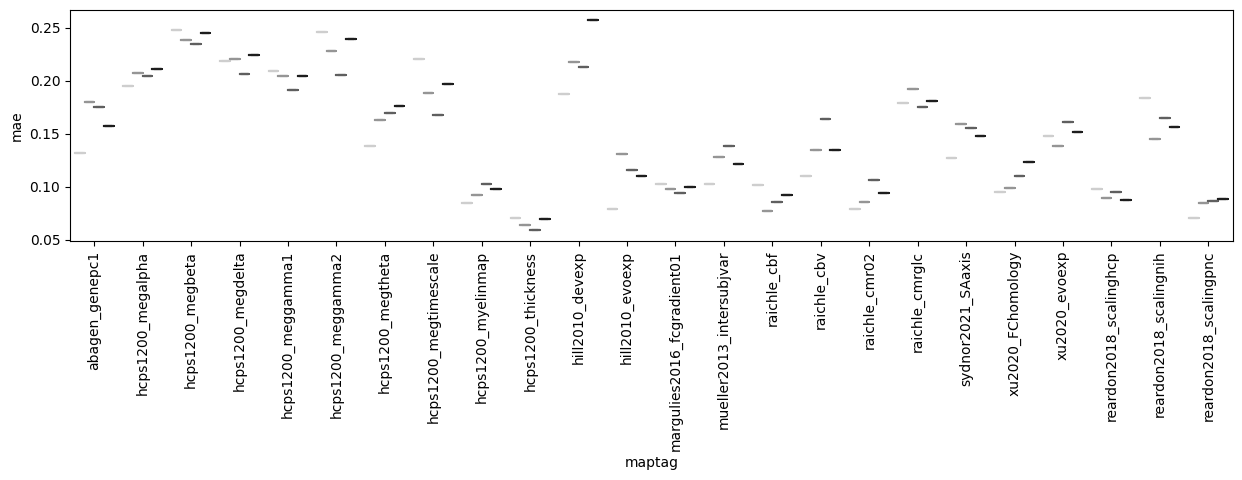

In [57]:
import seaborn as sns

plt.figure(figsize = (15,3))
sns.boxplot(variogram_gof_plotdata, x='maptag', y='mae', hue='percentage', palette=pct_colours, fill=False,legend=False)
plt.xticks(rotation = 90)

plt.show()

/tmp/ipykernel_813404/1391702532.py:4: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.boxplot(variogram_gof_plotdata, x='percentage', y='mae', hue='percentage', linewidth=2, palette = pct_colours, fill = False, linecolor = 'k', legend=False)


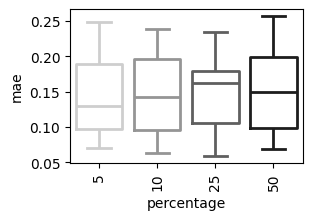

In [42]:
import seaborn as sns

plt.figure(figsize = (3,2))
sns.boxplot(variogram_gof_plotdata, x='percentage', y='mae', hue='percentage', linewidth=2, palette = pct_colours, fill = False, linecolor = 'k', legend=False)
plt.xticks(rotation = 90)

#plt.show()

plt.savefig(projdir + "/figs/main/neuromaps_fibonacci_variogram_fit_percentages.svg")

# Global Moran's I

In [9]:
# compute moran's I for the whole map
from interpmodules import helpers

global_i_s = pd.DataFrame(index = maptags, columns = ['i'])

Dist = helpers.internal_distance_matrix(src_pvdata.points)

for maptag in maptags:
    global_i = helpers.morans_i(Dist, src_pvdata[maptag])
    global_i_s.loc[maptag] = global_i

# arrange the data frame - this is hard coded
category = ['gene expression'] + ['MEG'] * 7 + ['structural'] * 2 + ['expansion']*2 + ['functional']*2 + ['metabolism']*4 + ['functional']*2 + ['expansion']*4
global_i_s['category'] = category

#global_i_s['pc1_scores'] = pca.components_[0]
#global_i_s['pc2_scores'] = pca.components_[1]
global_i_s = global_i_s.sort_values(by=['category', 'i'], ascending = True)
global_i_s.category = global_i_s.category.astype('category')
global_i_s.category = global_i_s.category.cat.set_categories(corder)
global_i_s = global_i_s.sort_values(["category", "i"])
joblib.dump(global_i_s, projdir + '/results/stats/neuromaps_full_global_i_s.pkl')

['/home/yzhou/gitrepo/interpolate//results/stats/neuromaps_full_global_i_s.pkl']

In [47]:
global_i_s = joblib.load(projdir + '/results/stats/neuromaps_full_global_i_s.pkl')

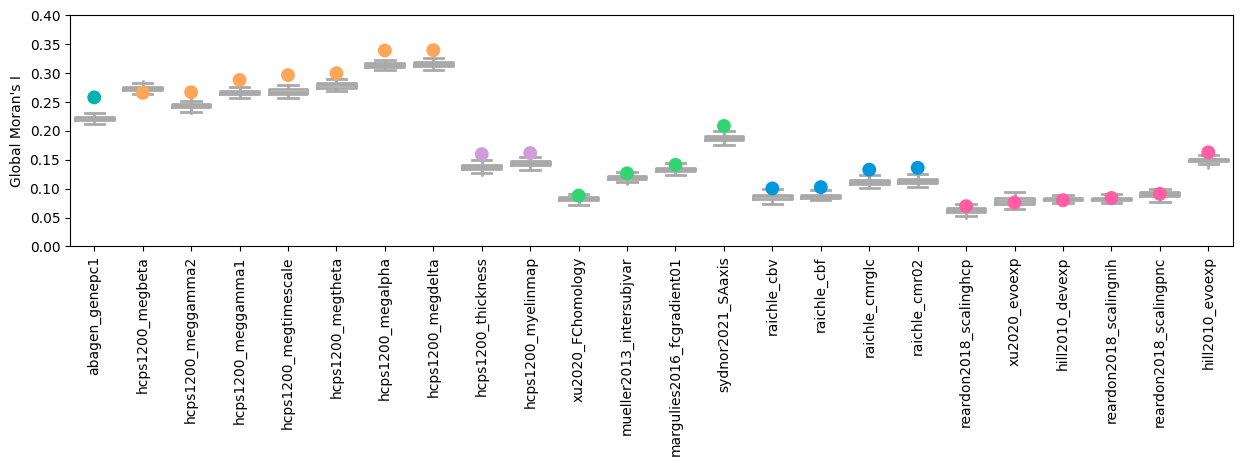

In [100]:
import seaborn as sns

plt.figure(figsize = (15,3))

sns.scatterplot(global_i_s, x=global_i_s.index, y='i', \
                hue = 'category', hue_order = corder, \
                palette = cpal, edgecolor = 'none',  s = 100, legend = False, zorder = 10
)

sns.boxplot( samples_i_s, color='darkgray', fliersize=1, linewidth = 2, fill=False)


plt.ylim([0,.4])
plt.xticks(rotation=90)
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("Global Moran's I")
plt.savefig(projdir + '/figs/main/neuromaps_surf_maps_moran_i.svg')

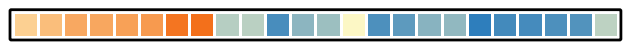

In [271]:
import matplotlib.patches as patches



fig, ax = plt.subplots()

data = global_i_s['i'].to_numpy().astype(float).reshape(1,-1)

sns.heatmap( data, \
             yticklabels = ['i'], xticklabels=global_i_s.index, \
             linewidth = 2, linecolor = 'w', cbar = False,\
             cmap = gnrd, square = True, ax=ax)

padding = 0.1
rect = patches.FancyBboxPatch(
    (-padding, 0 - padding),
    data.shape[1] + 2*padding,
    1 + 2*padding,
    boxstyle="round,pad=0,rounding_size=0.05",
    fill=False,
    edgecolor="k",
    linewidth=2
)
rect.set_clip_on(False)

ax.add_patch(rect)
ax.set_xticks([])
ax.set_yticks([])
ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()

#plt.show()
plt.savefig(projdir + '/figs/main/neuromaps_global_morans_i_row.svg')

# Samples Moran's I

In [10]:
# Compute global Moran's I for the samples

sample_global_i_s = np.zeros((len(test_percentages), len(maptags), niters))

for pi, percentage in enumerate(test_percentages):

    sampling = joblib.load( projdir + f'/data/sampling/{space}_{geometry}_samp-{strategy}_pct-{str(percentage)}_iters-100.pkl')
    known_coords, known_verts, unknown_coords, unknown_verts = sampling[1]

    for mi, maptag in enumerate(maptags):
        for j in range(niters):
            dj = helpers.internal_distance_matrix(known_coords[:,:,j])
            xj = src_pvdata[maptag][known_verts[:,j].flatten().astype(int)]
    
            sample_global_i_s[pi, mi, j] = helpers.morans_i(dj, xj)
# it took a while so i'm saving it
#np.save(projdir + '/results/neuromaps_samples_global_i_s.npy', sample_global_i_s)


KeyboardInterrupt

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fbcbc49ee90>>
Traceback (most recent call last):
  File "/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fbcbc49ee90>>
Traceback (most recent call last):
  File "/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [28]:
sample_global_i_s = np.load(projdir + '/results/stats/neuromaps_samples_global_i_s.npy')

In [29]:
sample_global_i_s.shape

(4, 24, 100)

In [30]:
samples_i_s = pd.DataFrame(sample_global_i_s.mean(axis=0).T, columns=[maptags], index=np.arange(100))

In [31]:
samples_i_s

,abagen_genepc1,hcps1200_megalpha,hcps1200_megbeta,hcps1200_megdelta,hcps1200_meggamma1,hcps1200_meggamma2,hcps1200_megtheta,hcps1200_megtimescale,hcps1200_myelinmap,hcps1200_thickness,...,raichle_cbf,raichle_cbv,raichle_cmr02,raichle_cmrglc,sydnor2021_SAaxis,xu2020_FChomology,xu2020_evoexp,reardon2018_scalinghcp,reardon2018_scalingnih,reardon2018_scalingpnc
0,0.218463,0.312362,0.271130,0.313955,0.266680,0.244970,0.278863,0.267099,0.136055,0.131317,...,0.086950,0.088495,0.106796,0.108163,0.183605,0.080613,0.076457,0.064959,0.086112,0.087084
1,0.217723,0.309152,0.271783,0.313250,0.261452,0.241833,0.274169,0.262510,0.135742,0.134955,...,0.084247,0.086726,0.107453,0.111133,0.181709,0.083158,0.084307,0.057946,0.082232,0.087376
2,0.212137,0.307452,0.268050,0.308950,0.261647,0.238183,0.275740,0.262070,0.136946,0.137473,...,0.083182,0.084769,0.103990,0.108435,0.182753,0.082800,0.080760,0.065040,0.088230,0.097878
3,0.220425,0.318843,0.264335,0.317120,0.272293,0.242716,0.281548,0.271531,0.143041,0.130392,...,0.085379,0.078232,0.118822,0.116849,0.182972,0.072244,0.076363,0.058351,0.075830,0.088138
4,0.220020,0.312036,0.274262,0.317134,0.264918,0.245100,0.274622,0.272514,0.138425,0.135162,...,0.088598,0.080292,0.112009,0.113239,0.189802,0.080514,0.064958,0.059339,0.080770,0.099467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.223148,0.314676,0.266517,0.309605,0.262588,0.230860,0.284760,0.259139,0.142773,0.141014,...,0.082059,0.083313,0.103311,0.104071,0.184490,0.084737,0.072654,0.067243,0.083820,0.084479
96,0.216955,0.310257,0.271337,0.313559,0.261336,0.240928,0.275412,0.263744,0.138286,0.134144,...,0.080089,0.079230,0.108015,0.107507,0.178405,0.075257,0.076172,0.049366,0.075167,0.077650
97,0.227710,0.314005,0.275404,0.316202,0.258965,0.234046,0.280758,0.264591,0.148351,0.140917,...,0.085503,0.078187,0.114303,0.111285,0.183443,0.085312,0.080611,0.066459,0.078193,0.091464
98,0.221712,0.308948,0.280257,0.307070,0.257149,0.232666,0.279909,0.260183,0.139361,0.136517,...,0.093768,0.093057,0.114854,0.111192,0.183526,0.085160,0.072118,0.064823,0.085621,0.094123


In [ ]:
joblib.dump(global_i_s, projdir + "/results/stats/neuromaps_full_global_i_s_mae.pkl')

In [16]:
global_i_s = joblib.load(projdir + "/results/stats/neuromaps_full_global_i_s_mae.pkl")

In [26]:
global_i_s['mae'] = variogram_gof_plotdata.groupby("maptag").mean().sort_values("mae", ascending = True)['mae']

In [27]:
joblib.dump(global_i_s, projdir + "/results/stats/neuromaps_full_global_i_s_mae_sill-normalized.pkl")

['/home/yzhou/gitrepo/interpolate//results/stats/neuromaps_full_global_i_s_mae_sill-normalized.pkl']

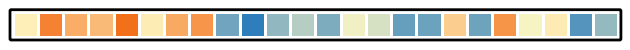

In [272]:
import matplotlib.patches as patches



fig, ax = plt.subplots()

data = global_i_s['mae'].to_numpy().astype(float).reshape(1,-1)

sns.heatmap( data, \
             yticklabels = ['mae'], xticklabels=global_i_s.index, \
             linewidth = 2, linecolor = 'w', cbar = False,\
             cmap = gnrd, square = True, ax=ax)

padding = 0.1
rect = patches.FancyBboxPatch(
    (-padding, 0 - padding),
    data.shape[1] + 2*padding,
    1 + 2*padding,
    boxstyle="round,pad=0,rounding_size=0.05",
    fill=False,
    edgecolor="k",
    linewidth=2
)
rect.set_clip_on(False)

ax.add_patch(rect)
ax.set_xticks([])
ax.set_yticks([])
ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()

#plt.show()
plt.savefig(projdir + '/figs/main/neuromaps_variogram_mae_row.svg')

In [29]:
global_i_s = joblib.load(projdir + "/results/stats/neuromaps_full_global_i_s_mae_sill-normalized.pkl")

In [30]:
pc_scores = pd.DataFrame({"maptag": maptags, \
                           "pc1": np.array(fpca.components_[0].data_matrix).flatten(), \
                           "pc2": np.array(fpca.components_[1].data_matrix).flatten()})

NameError: name 'fpca' is not defined

In [132]:
pc_scores.index = maptags

In [31]:
global_i_s

,i,category,mae,pc1_scores,pc2_scores,maptag,pc1,pc2
abagen_genepc1,0.258006,gene expression,0.423570,1.171887,-0.065749,abagen_genepc1,1.171887,-0.065749
hcps1200_megbeta,0.265799,MEG,0.190303,1.156071,-0.196890,hcps1200_megbeta,-0.123042,1.962203
hcps1200_meggamma2,0.267007,MEG,0.527487,-0.123042,1.962203,hcps1200_meggamma2,1.172595,-0.167125
hcps1200_meggamma1,0.288112,MEG,0.776975,1.111125,0.001216,hcps1200_meggamma1,1.170573,-0.338821
hcps1200_megtimescale,0.296607,MEG,0.833376,1.170573,-0.338821,hcps1200_megtimescale,1.167903,-0.319444
hcps1200_megtheta,0.299977,MEG,0.339182,1.172595,-0.167125,hcps1200_megtheta,1.119429,0.114326
hcps1200_megalpha,0.33919,MEG,0.640165,1.119429,0.114326,hcps1200_megalpha,1.156071,-0.196890
hcps1200_megdelta,0.339774,MEG,0.488461,1.167903,-0.319444,hcps1200_megdelta,1.111125,0.001216
hcps1200_thickness,0.159796,structural,0.044110,1.167855,0.246017,hcps1200_thickness,0.856953,1.241973
hcps1200_myelinmap,0.161553,structural,0.140468,0.856953,1.241973,hcps1200_myelinmap,1.167855,0.246017


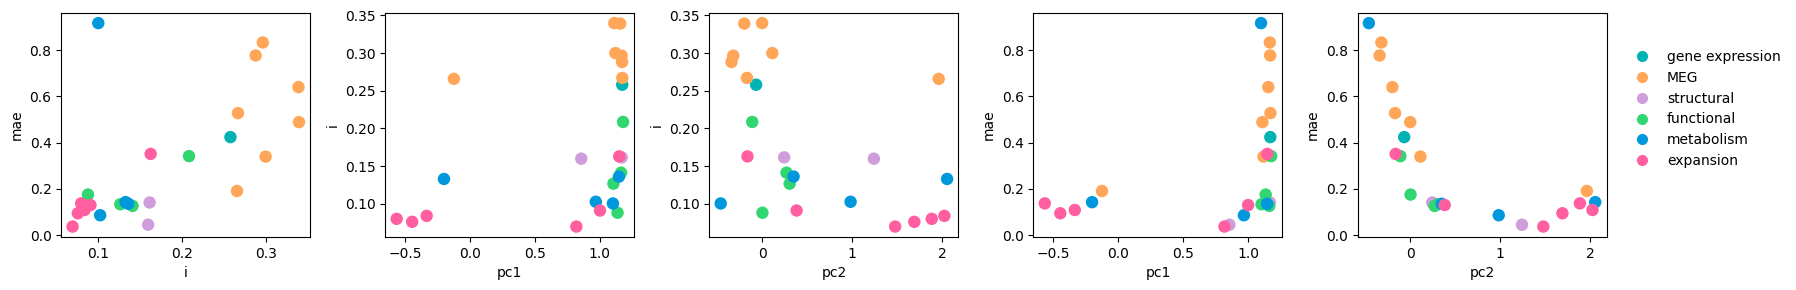

In [33]:
# add regression lines here

fig, axs = plt.subplots(1,5, figsize = (18,3))

sns.scatterplot( global_i_s, x='i', y='mae', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[0])

for i, measure in enumerate(['pc1', 'pc2']):
    
    sns.scatterplot( global_i_s, x=measure, y='i', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[i + 1])
    
sns.scatterplot( global_i_s, x='pc1', y='mae', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[3])

sns.scatterplot( global_i_s, x='pc2', y='mae', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[4])

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="k", linewidth =0, \
           markeredgecolor = 'none',\
           markerfacecolor=to_rgba(ccolours[ci]), markersize=8, \
           label=cat)
    for ci, cat in enumerate(corder)
]

plt.legend(handles=legend_elements, \
           loc='lower right', \
           frameon=False, \
           ncol = 1,\
            bbox_to_anchor=(1.75, 0.25),  # outside right
            borderaxespad=0.5)

plt.tight_layout()
#plt.show()
plt.savefig(projdir + '/figs/main/neuromaps_surf_maps_i_vs_mae_scatter_sill-normalized.svg')

In [34]:
global_i_s['mae'].min()

np.float64(0.03624641613124818)

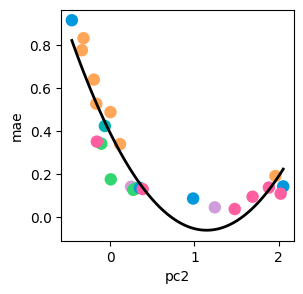

In [35]:
plt.figure(figsize = (3,3))
df = global_i_s

x = df["pc2"]
y = df["mae"]

coeffs = np.polyfit(x, y, 2)

# Create smooth curve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = np.polyval(coeffs, x_fit)

sns.scatterplot(data=df, x="pc2", y="mae", palette = cpal, hue='category', s=80, edgecolor = 'none', legend=False)
plt.plot(x_fit, y_fit, color = 'k', linewidth=2)

plt.savefig(projdir + '/figs/main/neuromaps_surf_maps_pc2_vs_mae_quadratic_sill-normalized.svg')

# Same scatter plot but with the samples

In [56]:
variogram_order = global_i_s.sort_values('mae', ascending = False).index

In [40]:
collected_stats = joblib.load( projdir + '/results/stats/neuromaps_collected_per_sample.pkl')

In [41]:
collected_stats

,krige,idw,regkrige,knn,rbf,swr,maptag,percentage,iteration,mae,sample_i
0,0.976190,0.857143,0.619048,0.547619,0.333333,0.166667,abagen_genepc1,5,0,0.131617,0.203859
1,1.000000,0.833333,0.642857,0.523810,0.309524,0.190476,abagen_genepc1,5,1,0.161916,0.211623
2,0.976190,0.738095,0.595238,0.595238,0.428571,0.166667,abagen_genepc1,5,2,0.181583,0.182106
3,1.000000,0.809524,0.404762,0.642857,0.476190,0.166667,abagen_genepc1,5,3,0.129122,0.221287
4,0.976190,0.761905,0.714286,0.500000,0.380952,0.166667,abagen_genepc1,5,4,0.154022,0.216959
...,...,...,...,...,...,...,...,...,...,...,...
9595,0.714286,0.523810,1.000000,0.666667,0.428571,0.166667,reardon2018_scalingpnc,50,95,0.077725,0.086410
9596,0.833333,0.523810,1.000000,0.619048,0.357143,0.166667,reardon2018_scalingpnc,50,96,0.081095,0.089332
9597,0.357143,0.666667,1.000000,0.785714,0.523810,0.166667,reardon2018_scalingpnc,50,97,0.078315,0.086995
9598,0.785714,0.690476,0.952381,0.476190,0.428571,0.166667,reardon2018_scalingpnc,50,98,0.079386,0.088395


# Interpolations

In [116]:
# top 5 covariates

import wrappers

cov5 = wrappers.generate_covariates(curr_map='hcps1200_thickness', src_polydata=src_pvdata, \
                             trg_polydata=src_pvdata, nspins=3000, datasource='neuromaps')


hcps1200_thickness
['raichle_cmr02' 'hcps1200_megdelta' 'hcps1200_myelinmap'
 'sydnor2021_SAaxis' 'abagen_genepc1']
[-0.48490684  0.51883381 -0.58260955  0.59771156 -0.69899677]


In [119]:
other_maps = src_pvdata.array_names
CMAT = np.ones(len(other_maps))
curr_map = 'hcps1200_thickness'

for j, other_map in enumerate(other_maps):
    
    if other_map == curr_map: continue

    CMAT[j] = np.ma.corrcoef(np.ma.masked_invalid(src_pvdata[curr_map]), \
                        np.ma.masked_invalid(src_pvdata[other_map]))[1,0]

In [128]:
chosen_map_idx = abs(CMAT).argsort()

In [131]:
chosen_map_idx = chosen_map_idx[:-1]
top5_cov = np.array(other_maps)[chosen_map_idx][-5:]
print(curr_map)
print(top5_cov)

hcps1200_thickness
['raichle_cmr02' 'hcps1200_megdelta' 'hcps1200_myelinmap'
 'sydnor2021_SAaxis' 'abagen_genepc1']


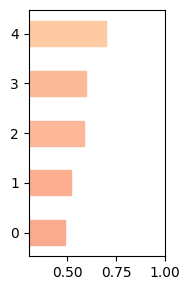

In [155]:
plt.figure(figsize = (2,3))
covariates_corr = abs(CMAT)[ chosen_map_idx[-5:] ]
bars = plt.barh(y=np.arange(5), height = .5, width=covariates_corr)

for bi, bar in enumerate(bars):
    bar.set_color(gny(covariates_corr[bi]))

plt.xlim([0.3,1])
plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_thickness_top5_covariates.svg')

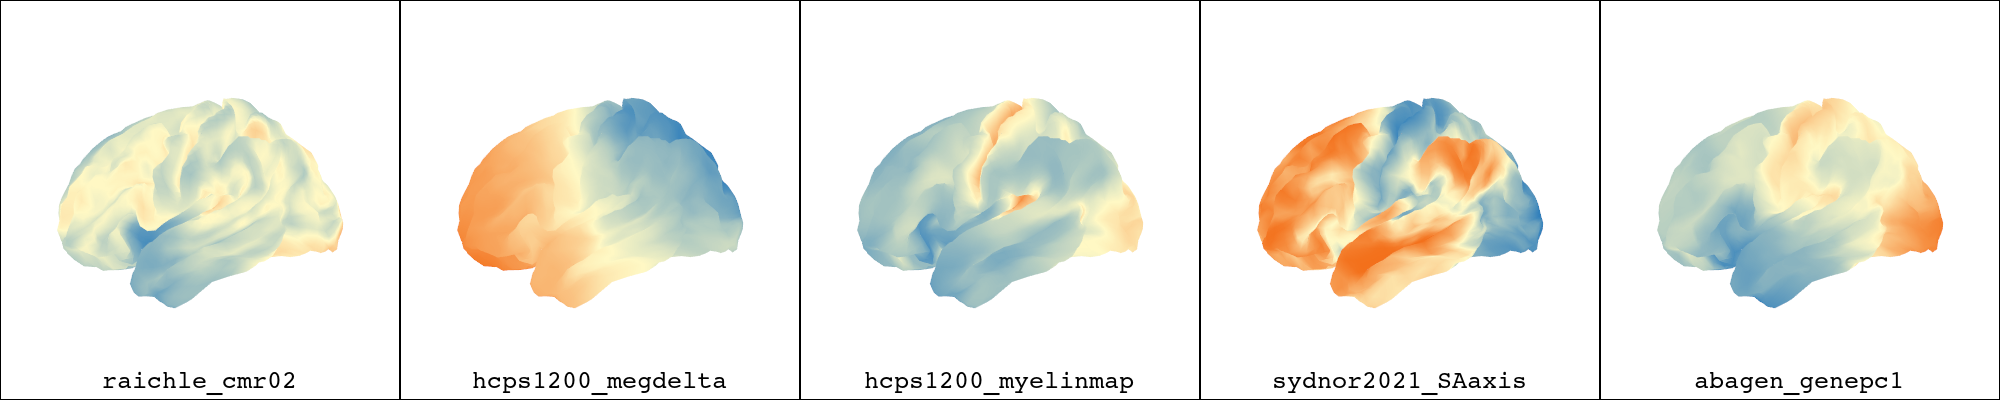

In [138]:
pl = pv.Plotter( shape = (1,5), window_size = (2000, 400))

for i, topcov in enumerate(top5_cov):

    pl.subplot(0,i)
    tmp_mesh = copy.deepcopy( src_pvdata )
    pl.add_mesh(tmp_mesh.rotate_z(180), scalars = topcov, cmap = gnrd, \
                **mesh_aes)
    pl.add_text(topcov, font_size = 10, font = 'courier', position = 'lower_edge')
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/neuromaps_top5_covariates_thickness_example.svg')

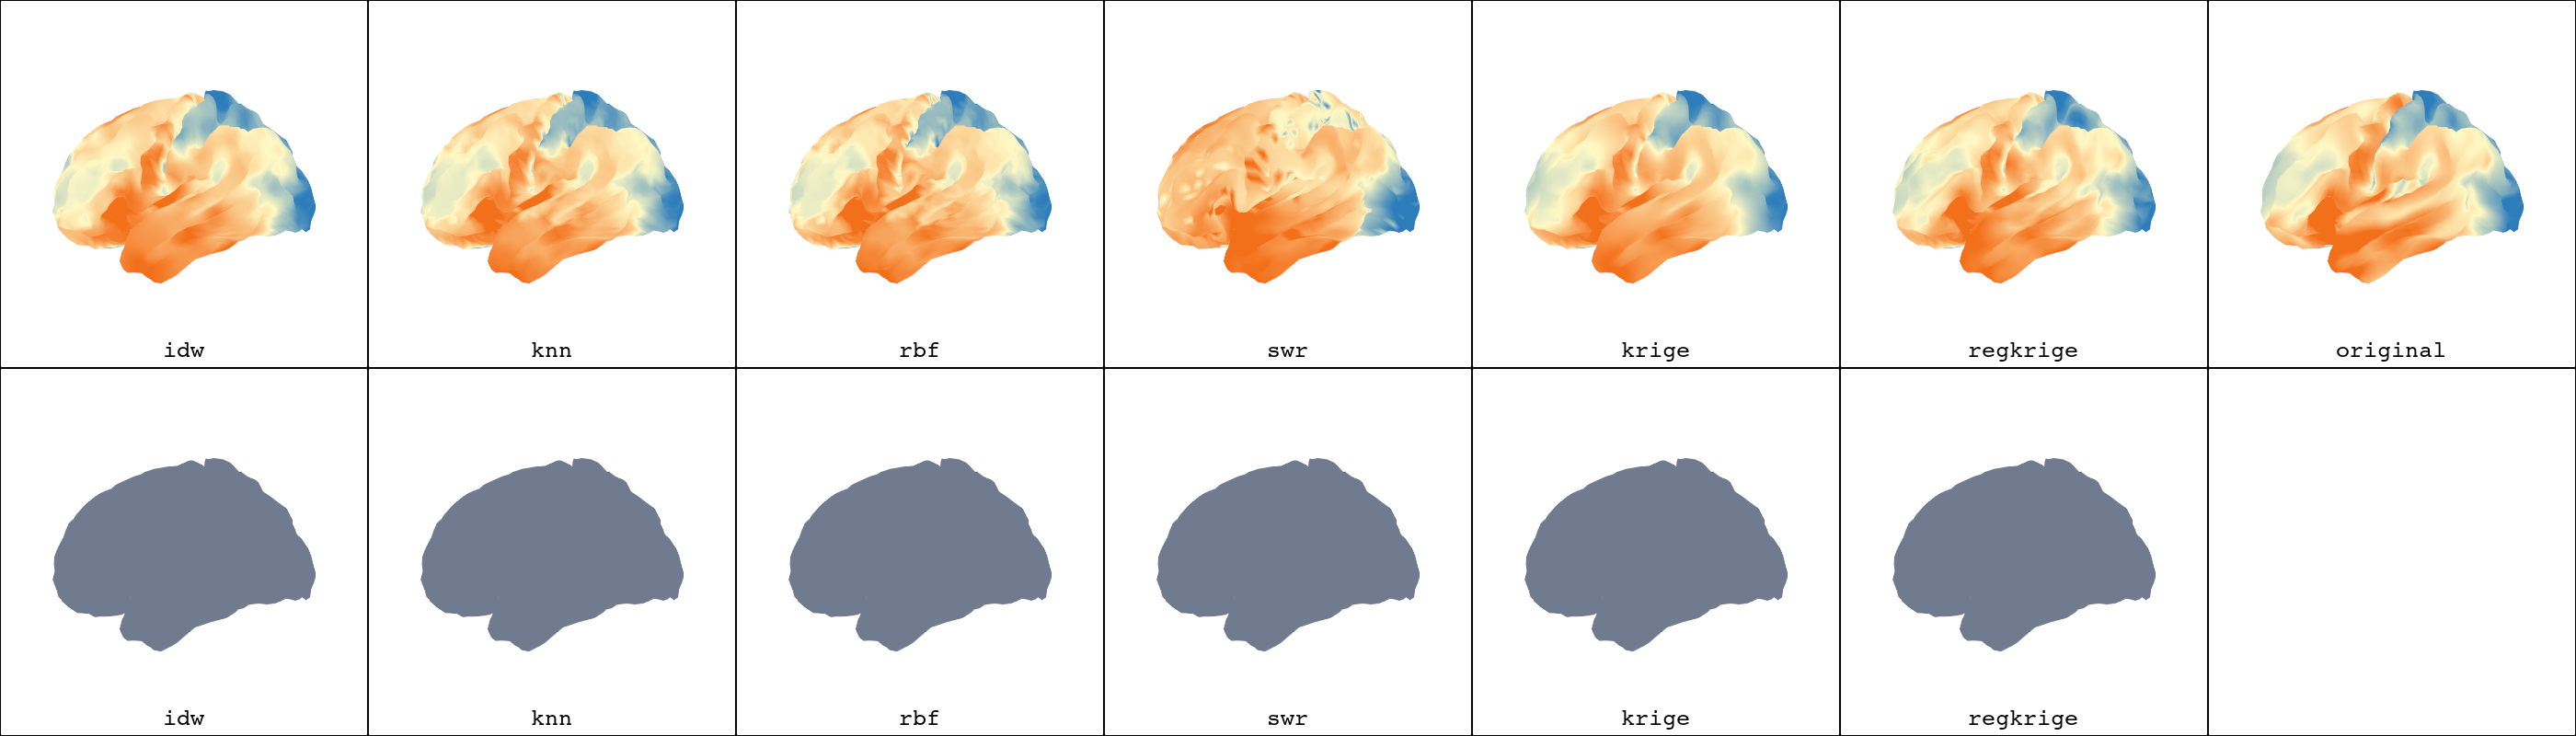

In [114]:
import copy
import pyvista as pv

pl = pv.Plotter(shape = (2,7), window_size = (2800, 800))

maptag = 'hcps1200_thickness'
strategy = 'dsk33'
labels, results = joblib.load(projdir + \
        f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-10.pkl')

tags, sampling = joblib.load( projdir + f'/data/sampling/{space}_{geometry}_samp-{strategy}_pct-10_iters-100.pkl')
known_coords, known_verts, unknown_coords, unknown_verts = sampling

for ai, approach in enumerate( approaches ):
    
    full_map = np.zeros((src_pvdata.n_points, niters))
    niters = 1
    for i in range(niters):
        full_map[unknown_verts[:,i].flatten().astype(int), i] = results[3][i][approach]
        full_map[known_verts[:,i].flatten().astype(int), i] = src_pvdata[maptag][known_verts[:,i].flatten().astype(int)]

    mean_map = np.mean(full_map, axis = 1)
    sd_map = np.std(full_map, axis = 1)
    
    pl.subplot(0, ai)
    tmp_mesh = copy.deepcopy( src_pvdata )
    pl.add_mesh(tmp_mesh.rotate_z(180), scalars = mean_map, cmap = gnrd, clim = (np.percentile(mean_map, 5), np.percentile(mean_map,95)), **mesh_aes)
    pl.add_text(approach, font_size = 10, font = 'courier', position = 'lower_edge')
    pl.camera_position = 'yz'

    pl.subplot(1,ai)
    tmp_mesh = copy.deepcopy( src_pvdata )
    pl.add_mesh(tmp_mesh.rotate_z(180), scalars = sd_map, cmap = gny, clim = (np.percentile(sd_map, 5), np.percentile(sd_map,95)), **mesh_aes)
    pl.add_text(approach, font_size = 10, font = 'courier', position = 'lower_edge')
    pl.camera_position = 'yz'
    

pl.subplot(0, 6)
tmp_mesh = copy.deepcopy( src_pvdata )
pl.add_mesh(tmp_mesh.rotate_z(180), scalars = src_pvdata[maptag], cmap = gnrd, clim = (np.percentile(full_map, 5), np.percentile(full_map,95)), **mesh_aes)
pl.add_text("original", font_size = 10, font='courier', position = "lower_edge")
pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/neuromaps_thickness_interp-at-10_as_example.svg')

# Performance

* Arrange data frame

In [32]:
concat_rank_scores = pd.DataFrame()
strategy = 'dsk33'
geometry = 'reduced-midthickness'
for mi, maptag in enumerate(maptags):
    for pi, percentage in enumerate(test_percentages):
    
        results = joblib.load( projdir + \
                               f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}_0_all_info.pkl')
        
        #perf_scores = results['performance'][0]
        rank_scores = results['performance'][1]

        concat_rank_scores[maptag + "-" + str(percentage) ] = rank_scores
#plt.savefig(projdir + "/figs/main/grf_random_samples_mean_rank_scores_heatmap.svg")

In [33]:
performance_info=concat_rank_scores.T

In [34]:
listmaps = []

for maptag in maptags:
    listmaps += [ maptag ] * 4

In [35]:
performance_info['maptag'] = listmaps

In [36]:
performance_info.index = np.arange(96)

In [37]:
performance_info['mae'] = variogram_gof_plotdata['mae']
performance_info['percentage'] = variogram_gof_plotdata['percentage']

NameError: name 'variogram_gof_plotdata' is not defined

In [226]:
df_long = performance_info.melt(
    id_vars=["maptag", "mae", "percentage"],
    value_vars=approaches,
    var_name="approach",
    value_name="rank"
)


In [228]:
df_long['i'] = np.zeros(len(df_long))

In [229]:
for row in range(len(df_long)):

    maptag = df_long.at[row, 'maptag']
    df_long.at[row, 'i'] = global_i_s.loc[maptag, 'i']

In [230]:
import statsmodels.formula.api as smf
df = df_long
df["approach"] = df["approach"].astype("category")
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "rank ~ C(approach) + C(percentage) + C(maptag)",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     21.31
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           2.95e-74
Time:                        13:57:04   Log-Likelihood:                 194.21
No. Observations:                 572   AIC:                            -324.4
Df Residuals:                     540   BIC:                            -185.2
Df Model:                          31                                         
Covariance Type:                  HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

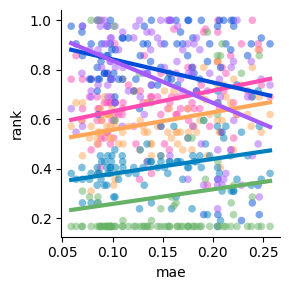

In [286]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df_long,
    x='mae',
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 30, "alpha": .5, "edgecolor": "none"},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_fibonacci_rank_vs_categorical_vars_scatter_alltogether.svg')

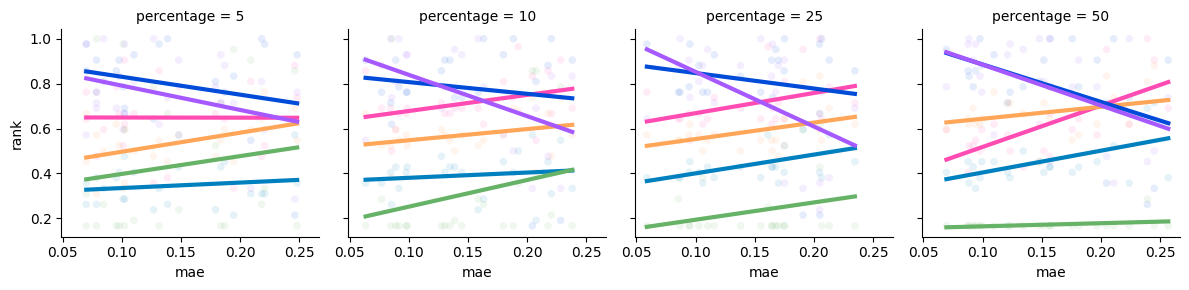

In [232]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df,
    x='mae',
    y="rank",
    hue="approach",
    col = "percentage",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 30, "alpha": .1, "edgecolor": "none"},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_fibonacci_rank_vs_categorical_vars_scatter_percentages.svg')

In [233]:
df_filtered = df.loc[df["approach"].isin(["regkrige", "krige"])]

In [234]:
df_filtered

,maptag,mae,percentage,approach,rank,i
384,abagen_genepc1,0.131617,5,krige,0.976190,0.229900
385,abagen_genepc1,0.180058,10,krige,0.928571,0.229900
386,abagen_genepc1,0.175175,25,krige,1.000000,0.229900
387,abagen_genepc1,0.157198,50,krige,1.000000,0.229900
388,hcps1200_meggamma2,0.246293,5,krige,0.214286,0.245756
...,...,...,...,...,...,...
571,reardon2018_scalingpnc,0.088550,50,regkrige,1.000000,0.089268
572,hill2010_evoexp,0.078668,5,regkrige,0.714286,0.151931
573,hill2010_evoexp,0.130503,10,regkrige,0.785714,0.151931
574,hill2010_evoexp,0.115809,25,regkrige,0.714286,0.151931


In [235]:
df_filtered = df_filtered.reset_index(drop=True)

In [236]:
import statsmodels.formula.api as smf
df = df_filtered
df["approach"] = df["approach"].astype("category")
df["approach"] = pd.Categorical(
    df["approach"],
    categories=["krige", "regkrige"],
    ordered=False
)
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "rank ~ mae + C(approach) + C(percentage) + C(maptag)",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     10.49
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           7.11e-24
Time:                        13:57:16   Log-Likelihood:                 108.89
No. Observations:                 188   AIC:                            -159.8
Df Residuals:                     159   BIC:                            -65.92
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

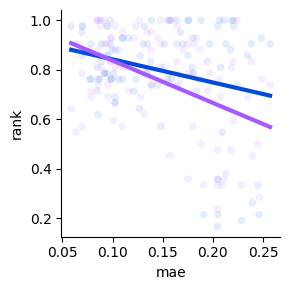

In [237]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df,
    x='mae',
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 30, "alpha": .1, "edgecolor": "none"},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_fibonacci_rank_vs_mae_krige_scatter_alltogether.svg')

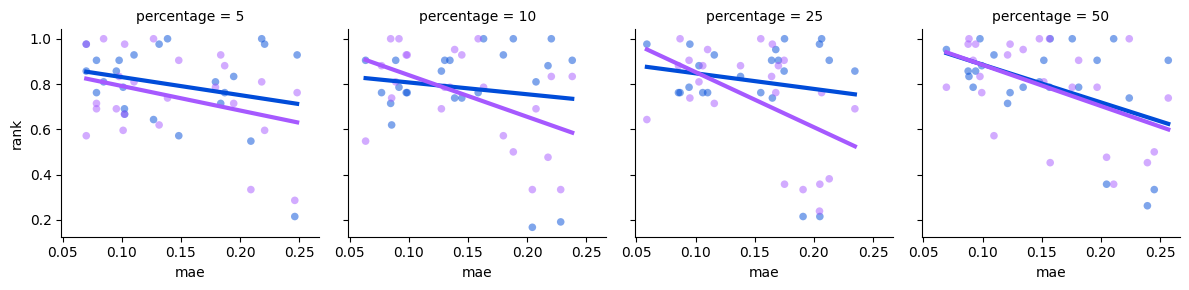

In [242]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df,
    x='mae',
    y="rank",
    hue="approach",
    col = "percentage",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 30, "alpha": .5, "edgecolor": "none"},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_fibonacci_rank_vs_mae_krige_scatter_percentage.svg')

In [243]:
tmp = df_long.groupby(['maptag', 'approach']).median('rank').sort_values('rank')

In [244]:
tmp['maptag'] = tmp.index.get_level_values(0)
tmp['approach'] = tmp.index.get_level_values(1)

In [245]:
tmp

,,mae,rank,i,maptag,approach
maptag,approach,,,,,
abagen_genepc1,swr,0.166187,0.166667,0.229900,abagen_genepc1,swr
hcps1200_megbeta,swr,0.241723,0.166667,0.272134,hcps1200_megbeta,swr
hcps1200_myelinmap,swr,0.094836,0.166667,0.148025,hcps1200_myelinmap,swr
hcps1200_megtimescale,swr,0.192660,0.166667,0.266267,hcps1200_megtimescale,swr
hcps1200_thickness,swr,0.066534,0.166667,0.150543,hcps1200_thickness,swr
...,...,...,...,...,...,...
abagen_genepc1,krige,0.166187,0.988095,0.229900,abagen_genepc1,krige
reardon2018_scalingpnc,regkrige,0.085836,1.000000,0.089268,reardon2018_scalingpnc,regkrige
hcps1200_megtheta,krige,0.166670,1.000000,0.278056,hcps1200_megtheta,krige


In [246]:
tmp.index = np.arange(len(tmp))

In [247]:
tmp

,mae,rank,i,maptag,approach
0,0.166187,0.166667,0.229900,abagen_genepc1,swr
1,0.241723,0.166667,0.272134,hcps1200_megbeta,swr
2,0.094836,0.166667,0.148025,hcps1200_myelinmap,swr
3,0.192660,0.166667,0.266267,hcps1200_megtimescale,swr
4,0.066534,0.166667,0.150543,hcps1200_thickness,swr
...,...,...,...,...,...
139,0.166187,0.988095,0.229900,abagen_genepc1,krige
140,0.085836,1.000000,0.089268,reardon2018_scalingpnc,regkrige
141,0.166670,1.000000,0.278056,hcps1200_megtheta,krige
142,0.219464,1.000000,0.317042,hcps1200_megdelta,krige


In [248]:
df_wide = tmp.pivot(
    index="maptag",
    columns="approach",
    values="rank"
)

In [249]:
df_wide

approach,idw,knn,krige,rbf,regkrige,swr
maptag,,,,,,
abagen_genepc1,0.809524,0.607143,0.988095,0.440476,0.511905,0.166667
hcps1200_megalpha,0.607143,0.523810,0.904762,0.309524,0.523810,0.738095
hcps1200_megbeta,0.726190,0.595238,0.880952,0.404762,0.726190,0.166667
hcps1200_megdelta,0.630952,0.583333,1.000000,0.333333,0.821429,0.190476
hcps1200_meggamma1,0.892857,0.773810,0.285714,0.583333,0.333333,0.726190
hcps1200_meggamma2,0.952381,0.773810,0.214286,0.619048,0.345238,0.607143
hcps1200_megtheta,0.607143,0.511905,1.000000,0.321429,0.785714,0.214286
hcps1200_megtimescale,0.607143,0.654762,0.964286,0.416667,0.678571,0.166667
hcps1200_myelinmap,0.630952,0.559524,0.845238,0.357143,0.916667,0.166667


In [250]:
df_wide = df_wide.reindex(global_i_s.index)

In [18]:
rorder = concat_rank_scores.T.mean().sort_values(ascending=False).index

In [252]:
df_wide = df_wide[rorder]

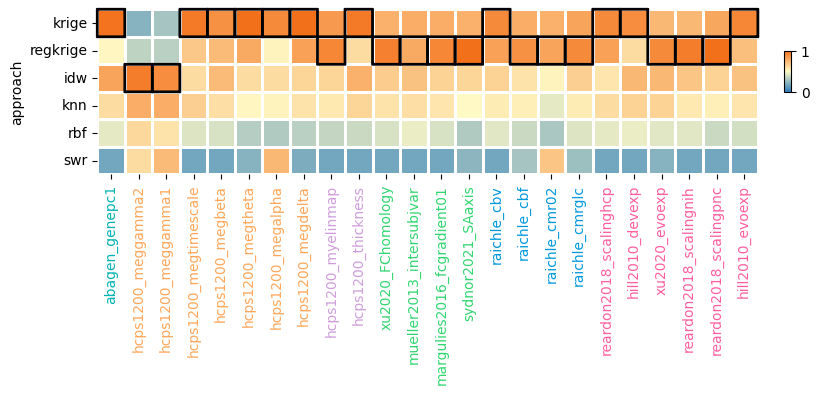

In [281]:
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize = (12,4))

data = df_wide.T

sns.heatmap( data, square = True, vmin = 0, vmax = 1, linewidth = 2, linecolor = 'w',cmap = gnrd, cbar = False, ax=ax)


for maptag in data.columns:
    col_label = maptag
    row_label = data[maptag].sort_values(ascending = False).index[0]

    i = data.index.get_loc(row_label)
    j = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor="k",
            facecolor="none", clip_on=False
        ))
    
for label in ax.get_xticklabels():

    cat_assign = global_i_s.loc[ label.get_text() ]['category']
    label.set_color(ccolours[corder.index(cat_assign)])


axins = inset_axes(
    ax,
    width="2%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower right",
    bbox_to_anchor=(0.55,0.5, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_fibonacci_surf_maps_even_ranks.svg')

In [20]:
concat_rank_scores

,abagen_genepc1-5,abagen_genepc1-10,abagen_genepc1-25,abagen_genepc1-50,hcps1200_megalpha-5,hcps1200_megalpha-10,hcps1200_megalpha-25,hcps1200_megalpha-50,hcps1200_megbeta-5,hcps1200_megbeta-10,...,reardon2018_scalinghcp-25,reardon2018_scalinghcp-50,reardon2018_scalingnih-5,reardon2018_scalingnih-10,reardon2018_scalingnih-25,reardon2018_scalingnih-50,reardon2018_scalingpnc-5,reardon2018_scalingpnc-10,reardon2018_scalingpnc-25,reardon2018_scalingpnc-50
krige,0.976190,0.928571,1.000000,1.000000,0.833333,0.809524,0.976190,1.000000,0.928571,0.904762,...,0.976190,0.857143,0.714286,0.738095,0.738095,0.785714,0.857143,0.714286,0.761905,0.833333
idw,0.857143,0.809524,0.809524,0.666667,0.333333,0.547619,0.666667,0.714286,0.738095,0.690476,...,0.547619,0.404762,0.714286,0.690476,0.690476,0.476190,0.642857,0.690476,0.642857,0.523810
regkrige,0.619048,0.571429,0.357143,0.452381,0.714286,0.690476,0.238095,0.357143,0.761905,0.833333,...,0.738095,0.976190,0.928571,0.928571,0.976190,1.000000,0.976190,1.000000,1.000000,1.000000
knn,0.547619,0.571429,0.642857,0.785714,0.452381,0.404762,0.595238,0.738095,0.547619,0.571429,...,0.619048,0.642857,0.547619,0.571429,0.500000,0.642857,0.452381,0.523810,0.547619,0.619048
rbf,0.333333,0.452381,0.523810,0.428571,0.214286,0.190476,0.404762,0.523810,0.357143,0.333333,...,0.452381,0.452381,0.428571,0.404762,0.428571,0.428571,0.261905,0.404762,0.380952,0.357143
swr,0.166667,0.166667,0.166667,0.166667,0.952381,0.857143,0.619048,0.166667,0.166667,0.166667,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.309524,0.166667,0.166667,0.166667


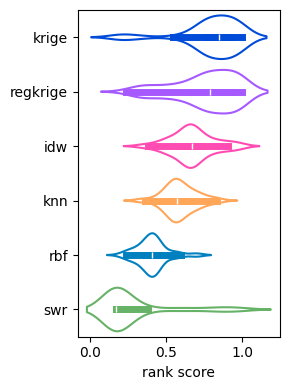

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (3,4), sharex=True)

sns.violinplot(concat_rank_scores.T, order = rorder, orient = 'h', inner = 'box', palette=apal,\
               fill=False, inner_kws=dict(box_width=5, whis_width=5), ax=ax)
ax.set_xlabel("rank score")
#sns.boxplot(concat_everything.T, order = methods_order, orient = 'h', fill=False, color = 'k', ax=axs[1], fliersize = 3)
#axs[1].set_xlabel("rank score")
# Increase median line width

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_surf_maps_even_ranks_violin.svg')

# Only Abagen

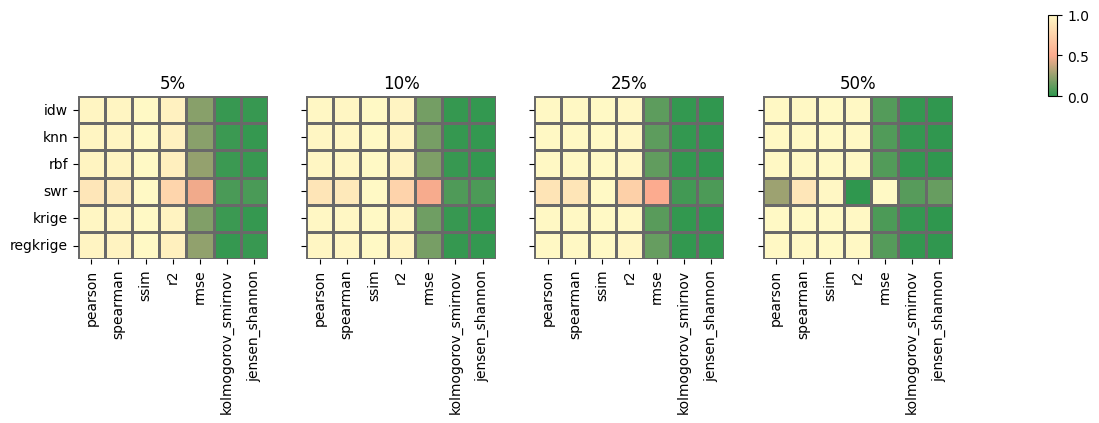

In [131]:
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


fig, axs = plt.subplots(1, len(test_percentages),figsize = (10, 10), sharey=True)

for pi, percentage in enumerate(test_percentages):

        results = joblib.load( projdir + \
                               f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}_0_all_info.pkl')
        
        perf_scores = results['performance'][0]

        sns.heatmap(perf_scores[:-1].T, square = True, cmap = gny, vmin = 0, vmax = 1, linecolor = "dimgray", linewidth = 1, cbar = False, ax=axs[pi])
        axs[pi].set_title(f"{percentage}%")
        
axins = inset_axes(
    axs[-1],
    width="5%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower left",
    bbox_to_anchor=(1.50, 1.0, 1, 1),
    bbox_transform=axs[-1].transAxes,
    borderpad=0,
)
norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gny), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)
plt.show()

#plt.savefig(projdir + "/figs/main/grf_random_samples_mean_rank_scores_heatmap.svg")

In [137]:
import pandas as pd

#concat_everything = pd.DataFrame()
niters = 1
concat_pct = pd.DataFrame()

for pi, percentage in enumerate(test_percentages):
    results = joblib.load(projdir + \
                    f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}_0_all_info.pkl')
    concat_iters = pd.concat( [ results['performance'][1] for i in range(niters) ], axis = 1)
    concat_pct = pd.concat( [concat_pct, concat_iters], axis = 1)

#concat_everything = pd.concat( [concat_everything, concat_pct ], axis = 1)

In [138]:
rorder = concat_pct.T.mean().sort_values(ascending=False).index

In [139]:
concat_pct

,0,0,0,0
krige,0.904762,0.904762,0.976190,0.952381
idw,0.809524,0.857143,0.619048,0.428571
knn,0.666667,0.666667,0.738095,0.785714
regkrige,0.523810,0.547619,0.428571,0.500000
rbf,0.428571,0.357143,0.571429,0.666667
swr,0.166667,0.166667,0.166667,0.166667


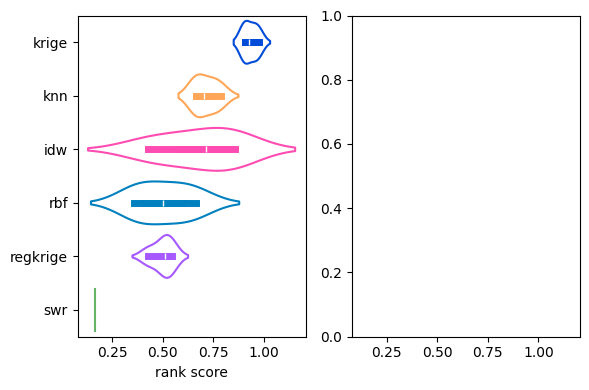

In [140]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,2, figsize = (6,4), sharex=True)

sns.violinplot(concat_pct.T, order = rorder, orient = 'h', inner = 'box', palette=apal,\
               fill=False, inner_kws=dict(box_width=5, whis_width=5), ax=axs[0])
axs[0].set_xlabel("rank score")
#sns.boxplot(concat_everything.T, order = methods_order, orient = 'h', fill=False, color = 'k', ax=axs[1], fliersize = 3)
#axs[1].set_xlabel("rank score")
# Increase median line width

plt.tight_layout()
plt.show()
#plt.savefig(projdir + '/figs/main/grf_random_samples_collapsed_rank_scores.svg')